In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

C:\Users\PERSONAL\AppData\Local\Temp\ipykernel_9804\3871542851.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed
C:\Users\PERSONAL\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.0084
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 2.4232e-04
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 2.0284e-04 
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.9136e-04
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.8163e-04
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.6651e-04
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.6489e-04
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.5646e-04
Epoch 9/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.5805e-04
Epoch 10/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.4673e-04
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step 

📊 Sample of Actual vs Predicted Prices:
Day 1: Actual = 133.33 | Predicted = 128.93
Day 2: Actual = 133.39 | Predicted = 129.78
Day 3: Actual = 135.95 | Predicted = 130.50
Day 4: Actual = 139.15 | Predicted = 131.44
Day 5: Actual = 140.55 | Predicted = 132.72

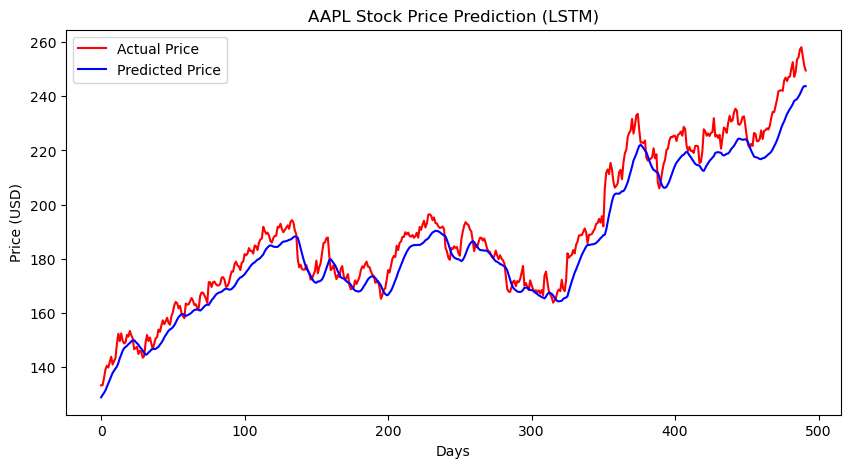

In [7]:
data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
prices = data['Close'].values  
#scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices.reshape(-1, 1))
# 🧱 Step 3: Prepare Sequences

X, y = [], []  
days = 60  

for i in range(days, len(scaled_prices)):
    past_window = scaled_prices[i - days:i, 0] 
    next_day_value = scaled_prices[i, 0]        

    X.append(past_window)
    y.append(next_day_value)

# Convert to numpy arrays
X_data = np.array(X)
y_data = np.array(y)

#Step 4Reshape Input

X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)
#Step 5: Split Train/Test
split = int(0.8 * len(X_data))
X_train, y_train = X_data[:split], y_data[:split]
X_test, y_test = X_data[split:], y_data[split:]
# Step 6: Build Model
model = Sequential([
    LSTM(50, input_shape=(X_data.shape[1], 1)),
    Dense(1)  
])

#Step 7: Compile & Train

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)
#Step 8: Make Predictions
predicted_scaled = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))
#  Step 9: Compare Results

print("\n📊 Sample of Actual vs Predicted Prices:")
print("=======================================")
for i in range(10):
    print(f"Day {i+1}: Actual = {actual_prices[i][0]:.2f} | Predicted = {predicted_prices[i][0]:.2f}")
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label='Actual Price', color='red')
plt.plot(predicted_prices, label='Predicted Price', color='blue')
plt.title('AAPL Stock Price Prediction (LSTM)')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

